# Análise de distribuições — desligado/ligado e mudança de regime

Plota o **histograma de cada sensor** de um equipamento para testar a hipótese de **duas
distribuições**:

1. **Desligado vs. ligado** — um cluster de valores baixos (equipamento parado) separado do
   regime de operação. Se existir e estiver no treino, polui o "normal" do modelo → vale
   filtrar (via `filter_threshold` no sensor de atividade).
2. **Mudança de regime no tempo** — o patamar normal se desloca entre períodos (ex.: pós-reparo
   o mancal opera +20 °C). Causa falso positivo sustentado → precisa **re-baselinar**.

Troque `EQUIP` (chave de `EQUIPMENT_CONFIGS`) no topo e reexecute.

> Robustez: sensores **mortos** (constantes) são descartados; o **% desligado** é medido entre
> as **leituras válidas** (ignora NaN).

In [1]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.mixture import GaussianMixture

ROOT = Path.cwd() if (Path.cwd() / "src").exists() else Path.cwd().parent
sys.path.insert(0, str(ROOT / "src"))
from transpetro_modelos.config import EQUIPMENT_CONFIGS
from transpetro_modelos.data.loading import load_equipment_data

# ── parâmetros ──
EQUIP = "B-4064A-prod"     # chave de EQUIPMENT_CONFIGS
DATA_FALHA = None          # ex.: "2024-08-30" (ou None = pega da config)
ACTIVITY_SENSOR = None     # força o sensor de atividade; None = detecta automaticamente

cfg = EQUIPMENT_CONFIGS[EQUIP]
if DATA_FALHA is None and getattr(cfg, "failure_date", None) is not None:
    DATA_FALHA = str(cfg.failure_date)[:10]
raw = load_equipment_data(EQUIP, from_clearml=False).select_dtypes(include=[np.number])
dead = [c for c in raw.columns if raw[c].std(skipna=True) == 0 or raw[c].notna().sum() == 0]
df = raw.drop(columns=dead)
cols = list(df.columns)
print(f"{EQUIP}: {df.shape[0]} linhas x {len(cols)} sensores vivos ({len(dead)} mortos) | "
      f"{str(df.index.min())[:10]} -> {str(df.index.max())[:10]} | falha={DATA_FALHA}")
if dead: print("mortos:", dead)
df.describe().T[["mean", "std", "min", "max"]]

B-4064A-prod: 43220 linhas x 8 sensores vivos (0 mortos) | 2024-01-01 -> 2026-03-27 | falha=2024-08-30


,mean,std,min,max
Corrente,25.531276,20.582353,-24.874193,100.500000
Pressão Descarga,21.294560,13.253380,-22.500000,40.644001
Pressão Sucção,5.652526,2.769599,-12.500000,16.900000
Temperatura Bomba LA,36.469759,11.296461,-25.000000,138.759995
Temperatura Bomba LNA,47.425649,17.160215,-25.000000,138.759995
Temperatura Motor LA,56.817621,21.428976,-25.000000,85.400002
Temperatura Motor LNA,52.607268,17.658233,-25.000000,76.360001
Vibração Bomba LNA,0.383758,1.547569,-3.175000,11.272519


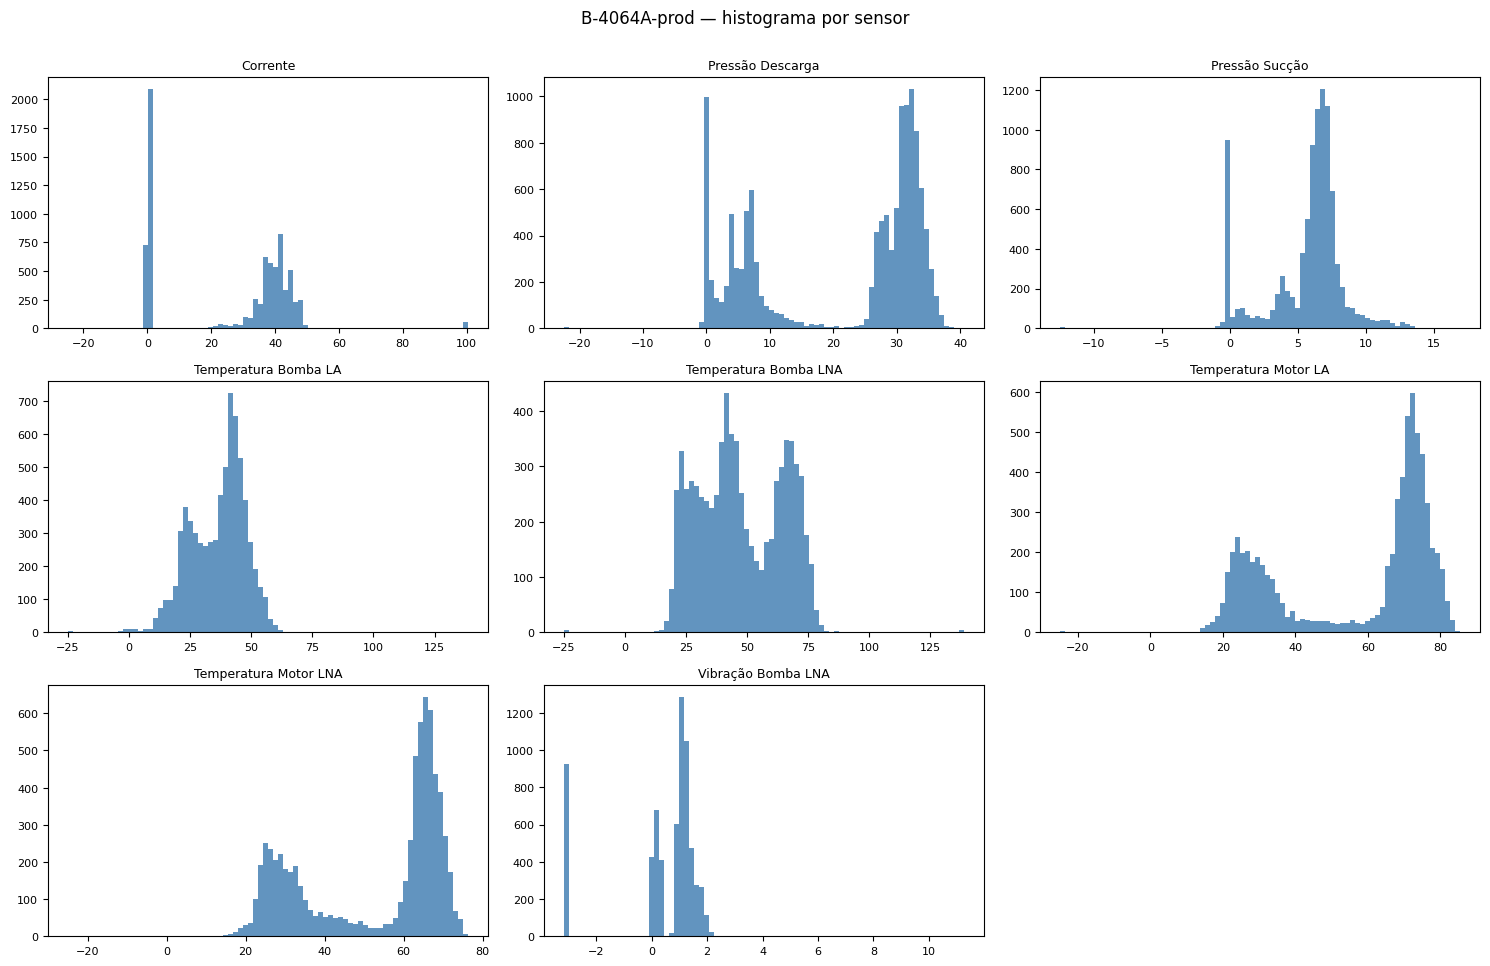

In [2]:
# Histograma de cada sensor vivo — visão geral da forma de cada distribuição
ncol = 3
nrow = int(np.ceil(len(cols) / ncol))
fig, axes = plt.subplots(nrow, ncol, figsize=(15, 3.2 * nrow))
axes = np.atleast_1d(axes).ravel()
for ax, c in zip(axes, cols):
    ax.hist(df[c].dropna().values, bins=80, color="steelblue", alpha=0.85)
    ax.set_title(c, fontsize=9); ax.tick_params(labelsize=8)
for ax in axes[len(cols):]:
    ax.axis("off")
fig.suptitle(f"{EQUIP} — histograma por sensor", y=1.002)
fig.tight_layout(); plt.show()

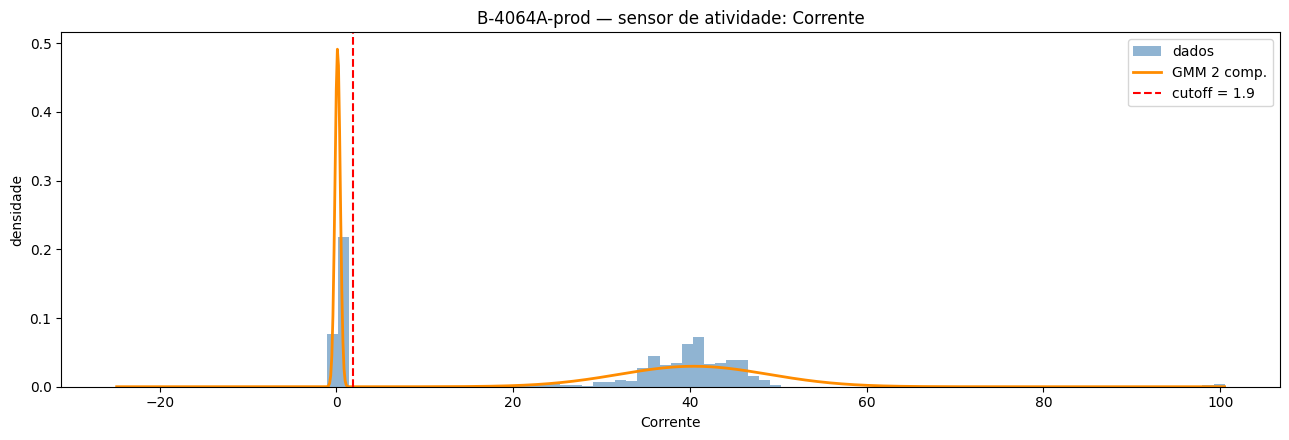

BIC(1)=67716  BIC(2)=45379  gap=4.78σ  -> bimodal=True
modos em 0.128 (desligado) e 40.4 (ligado)
cutoff sugerido (filter_threshold em Corrente): 1.905  | desligado: 37.0% das leituras válidas


In [3]:
# Sensor de ATIVIDADE (liga/desliga): corrente/vazão de maior amplitude; senão maior CV
def pick_activity(live):
    for kw in ("corrente", "current", "vaz", "flow"):
        cand = [c for c in live.columns if kw in c.lower()]
        if cand:
            return max(cand, key=lambda c: live[c].max() - live[c].min())
    cv = (live.std() / live.mean().abs().replace(0, np.nan)).abs()
    return cv.idxmax()

ACT = ACTIVITY_SENSOR or pick_activity(df)
xs = df[ACT].dropna().values; x = xs.reshape(-1, 1)

g1 = GaussianMixture(1, random_state=0).fit(x); g2 = GaussianMixture(2, random_state=0).fit(x)
bic1, bic2 = g1.bic(x), g2.bic(x)
means = np.sort(g2.means_.ravel()); stds = np.sqrt(g2.covariances_.ravel())
gap = abs(means[1] - means[0]) / max(stds)
bimodal = (bic2 < bic1) and (gap > 2)

cutoff = off_frac = None
if bimodal:
    grid = np.linspace(means[0], means[1], 500).reshape(-1, 1)
    cutoff = float(grid[np.argmin(np.exp(g2.score_samples(grid)))][0])
    off_frac = float((xs < cutoff).mean())   # entre leituras válidas (sem NaN)

fig, ax = plt.subplots(figsize=(13, 4.5))
ax.hist(xs, bins=100, density=True, color="steelblue", alpha=0.6, label="dados")
grid = np.linspace(xs.min(), xs.max(), 1000).reshape(-1, 1)
ax.plot(grid.ravel(), np.exp(g2.score_samples(grid)), color="darkorange", lw=2, label="GMM 2 comp.")
if cutoff is not None:
    ax.axvline(cutoff, color="red", ls="--", lw=1.5, label=f"cutoff = {cutoff:.3g}")
ax.set_title(f"{EQUIP} — sensor de atividade: {ACT}")
ax.set_xlabel(ACT); ax.set_ylabel("densidade"); ax.legend(); fig.tight_layout(); plt.show()

print(f"BIC(1)={bic1:.0f}  BIC(2)={bic2:.0f}  gap={gap:.2f}σ  -> bimodal={bimodal}")
if bimodal:
    print(f"modos em {means[0]:.3g} (desligado) e {means[1]:.3g} (ligado)")
    print(f"cutoff sugerido (filter_threshold em {ACT}): {cutoff:.4g}  | desligado: {off_frac:.1%} das leituras válidas")
else:
    print("sem cluster desligado claro (distribuição unimodal no sensor de atividade).")

## Mudança de regime no tempo

Sobrepõe a distribuição de cada sensor **por ano**, apenas no **estado ligado** (para não
confundir com duty cycle). Se o patamar (média) se desloca de forma sustentada entre anos —
sobretudo depois da falha/reparo — é mudança de regime: o modelo calibrado no regime antigo gera
falso positivo no novo e precisa ser **re-baselinado**.

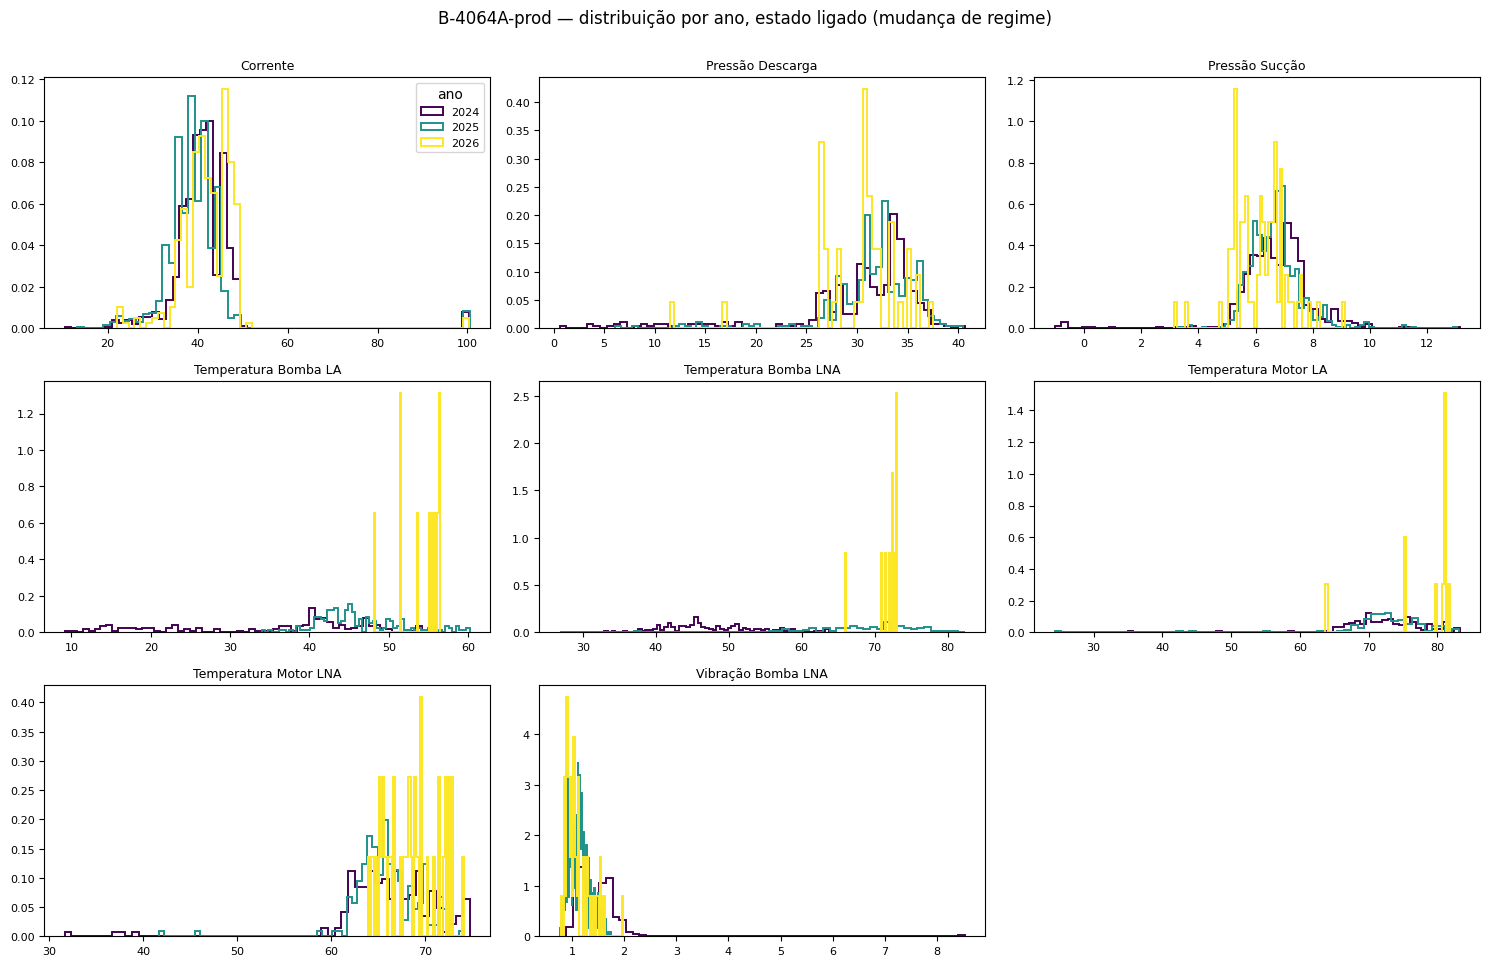

média por ano (estado ligado):


,2024,2025,2026
Corrente,41.51,39.37,42.48
Pressão Descarga,30.16,31.67,30.15
Pressão Sucção,6.70,6.68,6.16
Temperatura Bomba LA,35.24,46.33,54.23
Temperatura Bomba LNA,47.30,68.29,71.73
Temperatura Motor LA,72.48,72.88,78.37
Temperatura Motor LNA,66.17,65.99,68.49
Vibração Bomba LNA,1.43,1.14,1.11


In [4]:
base = df[df[ACT] >= cutoff] if cutoff is not None else df
anos = sorted(base.index.year.unique())
cmap = plt.cm.viridis(np.linspace(0, 1, len(anos)))
fig, axes = plt.subplots(nrow, ncol, figsize=(15, 3.2 * nrow))
axes = np.atleast_1d(axes).ravel()
for ax, c in zip(axes, cols):
    for ano, cor in zip(anos, cmap):
        xa = base.loc[base.index.year == ano, c].dropna().values
        if len(xa):
            ax.hist(xa, bins=60, density=True, histtype="step", color=cor, lw=1.4, label=str(ano))
    ax.set_title(c, fontsize=9); ax.tick_params(labelsize=8)
for ax in axes[len(cols):]:
    ax.axis("off")
axes[0].legend(fontsize=8, title="ano")
fig.suptitle(f"{EQUIP} — distribuição por ano, estado ligado (mudança de regime)", y=1.002)
fig.tight_layout(); plt.show()

media_ano = base.groupby(base.index.year).mean().T
media_ano.columns = [str(a) for a in media_ano.columns]
print("média por ano (estado ligado):")
media_ano.round(2)